# Scraping the PDB with Batch Requests
## CRIS Lab - Diffusioners

In [2]:
import json
import requests
import itertools
from collections import defaultdict

import matplotlib.pyplot as plt

# RBSC GraphQL Schema

We will use a graphql API with a schema adapted for rbsc. The documentation explorer [on this link](https://data.rcsb.org/graphql/index.html) provides documentation for the schema. 

Unfortunatley, ChatGPT isn't too fluent in this schema so we may actually have to put on our thinking caps if we need new types of queries :(

In [3]:
url = "https://data.rcsb.org/graphql"

In [14]:
import requests

# Base URL for the RCSB PDB Search API
url = "https://search.rcsb.org/rcsbsearch/v1/query"

# Define query parameters with Homo sapiens taxonomy (ID: 9606)
query = {
    "query": {
        "type": "terminal",
        "service": "structure",
        "parameters": {
            "term": "tax_id:9606",  # Homo sapiens taxonomy ID
            "facet": "none"
        }
    },
    "return_type": "entry",
    "limit": 1000
}

# Send the query request
response = requests.post(url, json=query)

# Check if the request was successful
if response.status_code == 200:
    data = response.json()
    # Extract the entry IDs (PDB IDs)
    entry_ids = [entry["identifier"] for entry in data["result_set"]]
    print(entry_ids)
else:
    print(f"Error fetching data: {response.status_code}")


Error fetching data: 404


# Obtain Resiude Sequences of Polymeric Entities in a Given PDB Structure

We supply a batch of entry_ids, which uniquely identify structures cataloged in the Protein Data Bank (PDB). We return a dictionary containing the residue sequences (as strings) for each polymeric entity belogining to each PDB structure we provide the entry_id of. These are sequences for each ploymeric unit; we can further subdivide each polymeric unit into strands, and we'll do that in later cells. 

In [4]:
# Supply a list of PDB "entry_ids" - these identify structures
# We will need to think of ways to identify a large, structured set of entry id's 
pdb_ids = ["9GSS", "1A1B"]

# JSON Query using the rbsc GraphQL schema 
query = {
    "query": """
    query getSequences($ids: [String!]!) {
        entries(entry_ids: $ids) {
            rcsb_id
            polymer_entities {
                entity_poly {
                    pdbx_seq_one_letter_code_can
                }
            }
        }
    }
    """,
    "variables": {"ids": pdb_ids},
}
entity_seqs = {}
response = requests.post(url, json=query)
data = response.json()
for entry in data["data"]["entries"]:
    pdb_id = entry["rcsb_id"]
    sequences = [poly["entity_poly"]["pdbx_seq_one_letter_code_can"] for poly in entry["polymer_entities"]]
    print(f"{pdb_id}: {sequences}")
    entity_seqs[pdb_id] = sequences

9GSS: ['PPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKASCLYGQLPKFQDGDLTLYQSNTILRHLGRTLGLYGKDQQEAALVDMVNDGVEDLRCKYISLIYTNYEAGKDDYVKALPGQLKPFETLLSQNQGGKTFIVGDQISFADYNLLDLLLIHEVLAPGCLDAFPLLSAYVGRLSARPKLKAFLASPEYVNLPINGNGKQ']
1A1B: ['XYEX', 'MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP']


# Identify Chains (strand_ids) of each polymeric unit in a Strcuture

Each Polymeric Entity (Polymer Unit) in a PDB structure is broken down futher into strands (alpha chain, beta chain, etc). This query recieves a batch of entry id's and returns a list containing the strand id's (Typically letters A, B, etc.) of each polymeric unit of each structure id'd in the batch. 

In [5]:
query = {
    "query": """
    query getSequences($ids: [String!]!) {
        entries(entry_ids: $ids) {
            rcsb_id
            polymer_entities {
                entity_poly {
                    pdbx_strand_id
                }
            }
        }
    }
    """,
    "variables": {"ids": pdb_ids},
}

url = "https://data.rcsb.org/graphql"
response = requests.post(url, json=query)
data = response.json()

chain_dict = {}
for entry in data["data"]["entries"]:
    pdb_id = entry["rcsb_id"]
    strands = [poly["entity_poly"]["pdbx_strand_id"] for poly in entry["polymer_entities"]]
    chain_dict[pdb_id] = strands
    print(f"{pdb_id}: {strands}")

9GSS: ['A,B']
1A1B: ['A,B', 'C,D']


## Obtain Explicit Residue Sequences for all Chains in all Polymeric Units of a Structure

Finally, we obtain the explicit sequence of resiudes for each chain in a structure (which are spread across the Polymeric Units of the structure). We return strings of the resiude sequences for each chain in each polymeric unit for each structure id'd in a batch of entry_id's. 

### First we need to format results we've queried in the prevous cell

In [6]:
instance_ids = []
unit_dict = {}
chain_seq_dict = {}

for id, strand_list in chain_dict.items():
    unit_dict[id] = {}
    chain_seq_dict[id] = {}
    for i, unit in enumerate(strand_list):
        unit_dict[id][i] = []
        chain_seq_dict[id][i] = {}
        strand = unit.split(',')
        for s in strand:
            temp = unit_dict[id][i]
            temp.append(s)
            unit_dict[id][i] = temp
            instance_ids.append(f"{id}.{s}")

print(instance_ids)
print(unit_dict)

['9GSS.A', '9GSS.B', '1A1B.A', '1A1B.B', '1A1B.C', '1A1B.D']
{'9GSS': {0: ['A', 'B']}, '1A1B': {0: ['A', 'B'], 1: ['C', 'D']}}


We finally obtain our desired dictionary of chain sequences

In [7]:
query = """
query getSequences($instance_ids: [String!]!) {
  polymer_entity_instances(instance_ids: $instance_ids) {
    polymer_entity {
      entity_poly {
        pdbx_seq_one_letter_code_can
      }
    }
  }
}
"""

variables = {"instance_ids": instance_ids}
response = requests.post(url, json={"query": query, "variables": variables})
data = response.json()
for i, instance in enumerate(data["data"]["polymer_entity_instances"]):
  ent = instance["polymer_entity"]["entity_poly"]["pdbx_seq_one_letter_code_can"]
  key, element = instance_ids[i].split('.')
  
  found_subkey = None
  for subkey, values in unit_dict[key].items():
    if element in values:
      found_subkey = subkey
      chain_seq_dict[key][found_subkey][element] = ent
      break

print(chain_seq_dict)

{'9GSS': {0: {'A': 'PPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKASCLYGQLPKFQDGDLTLYQSNTILRHLGRTLGLYGKDQQEAALVDMVNDGVEDLRCKYISLIYTNYEAGKDDYVKALPGQLKPFETLLSQNQGGKTFIVGDQISFADYNLLDLLLIHEVLAPGCLDAFPLLSAYVGRLSARPKLKAFLASPEYVNLPINGNGKQ', 'B': 'PPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKASCLYGQLPKFQDGDLTLYQSNTILRHLGRTLGLYGKDQQEAALVDMVNDGVEDLRCKYISLIYTNYEAGKDDYVKALPGQLKPFETLLSQNQGGKTFIVGDQISFADYNLLDLLLIHEVLAPGCLDAFPLLSAYVGRLSARPKLKAFLASPEYVNLPINGNGKQ'}}, '1A1B': {0: {'A': 'MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP', 'B': 'XYEX'}, 1: {'C': 'MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP', 'D': 'XYEX'}}}


## Interlude

Using the above code, we can access the resiudes of each subchain/subunit in a PDB structure. Ultimatley, I imagine we can use an efficiently-packaged version of this code to scrape the PDB for a bunch of Alphafold3 inputs (resiude sequences). 

Before we even think about the diffusion module, we can study the trunk features generated for each input sequence. Each resiude sequence is tokenized, and features are generated for every tokens by itself and all pairs of tokens. The CRIS lab is pretty jazzed about something called Zipf's Law; it's actually a linguistics thing, and has to do with an emergent distribution in the frequency of words in a "language".



In [8]:
residues = [
    'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y',  # Standard amino acids
    'X', 'B', 'Z', 'J', 'U', '*', '.', '-', '#'
]

single_res = {f'{a}': 0 for a in residues}
pairwise_res = {f'{a}{b}': 0 for a, b in itertools.product(residues, repeat=2)}
triwise_res = {f'{a}{b}{c}': 0 for a, b, c in itertools.product(residues, repeat=3)}

In [9]:
def get_leaf_values(d):
    if isinstance(d, dict):
        return list(map(get_leaf_values, d.values()))  # Recursively call get_leaf_values on dictionary values
    else:
        return [d]  # Return the value if it's not a dictionary

# Flatten the list of lists
def flatten(values):
    return sum(values, [])

all_seqs = flatten(flatten(flatten(get_leaf_values(chain_seq_dict))))

(array([11.,  2.,  2.,  5.,  7.,  1.,  0.,  0.,  0.,  1.]),
 array([ 0. ,  8.6, 17.2, 25.8, 34.4, 43. , 51.6, 60.2, 68.8, 77.4, 86. ]),
 <BarContainer object of 10 artists>)

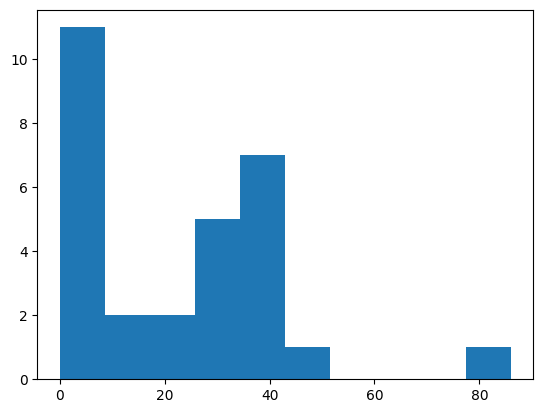

In [10]:
def count_res(strings, res):
    return sum(s.count(res) for s in strings)

vals = []

for res in residues:
    vals.append(count_res(all_seqs, res))

plt.hist(vals)

# END!!!!!!

In [20]:
for id, unit in chain_seq_dict.items():
    for u, strand in unit.items():
        for s, seq in strand.items():
            print(s, seq)

# Define the amino acid sequence
sequence = aa_dict["9GSS"]

# Create a defaultdict to store the counts of pairs
pair_counts = defaultdict(int)

# Iterate through the sequence and count each consecutive pair of amino acids
for i in range(len(sequence) - 1):
    pair = sequence[i:i+2]
    pair_counts[pair] += 1

# Print the pair counts
for pair, count in pair_counts.items():
    print(f"{pair}: {count}")

PP: 1
PY: 1
YT: 2
TV: 2
VV: 2
VY: 1
YF: 1
FP: 2
PV: 1
VR: 1
RG: 1
GR: 3
RC: 2
CA: 1
AA: 2
AL: 3
LR: 3
RM: 1
ML: 1
LL: 6
LA: 3
AD: 2
DQ: 3
QG: 2
GQ: 3
QS: 2
SW: 1
WK: 1
KE: 1
EE: 1
EV: 2
VT: 1
VE: 2
ET: 2
TW: 1
WQ: 1
QE: 2
EG: 1
GS: 1
SL: 2
LK: 3
KA: 3
AS: 2
SC: 1
CL: 2
LY: 3
YG: 2
QL: 2
LP: 3
PK: 2
KF: 1
FQ: 1
QD: 1
DG: 2
GD: 2
DL: 3
LT: 1
TL: 3
YQ: 1
SN: 1
NT: 1
TI: 1
IL: 1
RH: 1
HL: 1
LG: 2
RT: 1
GL: 1
GK: 4
KD: 2
QQ: 1
EA: 2
LV: 1
VD: 1
DM: 1
MV: 1
VN: 2
ND: 1
GV: 1
ED: 1
CK: 1
KY: 1
YI: 1
IS: 2
LI: 2
IY: 1
TN: 1
NY: 1
YE: 1
AG: 1
DD: 1
DY: 2
YV: 3
VK: 1
PG: 2
KP: 1
PF: 1
FE: 1
LS: 3
SQ: 1
QN: 1
NQ: 1
GG: 1
KT: 1
TF: 1
FI: 1
IV: 1
VG: 2
QI: 1
SF: 1
FA: 1
YN: 1
NL: 2
LD: 2
IH: 1
HE: 1
VL: 1
AP: 1
GC: 1
DA: 1
AF: 2
PL: 1
SA: 2
AY: 1
RL: 1
AR: 1
RP: 1
KL: 1
FL: 1
SP: 1
PE: 1
EY: 1
PI: 1
IN: 1
NG: 2
GN: 1
KQ: 1


In [60]:
pdb_ids = ["1A22"]  # List of PDB IDs
query = {
    "query": """
    query getSequences($ids: [String!]!) {
        entries(entry_ids: $ids) {
            rcsb_id
            polymer_entities {
                entity_poly {
                    pdbx_strand_id
                }
            }
        }
    }
    """,
    "variables": {"ids": pdb_ids},
}

url = "https://data.rcsb.org/graphql"
response = requests.post(url, json=query)
data = response.json()

chain_dict = {}
for entry in data["data"]["entries"]:
    pdb_id = entry["rcsb_id"]
    strands = [poly["entity_poly"]["pdbx_strand_id"] for poly in entry["polymer_entities"]]
    chain_dict
    print(f"{pdb_id}: {strands}")

1A22: ['A', 'B']


In [49]:
ids = "1A1B"
chains = ['A', 'B', 'C', 'D']


# Define the GraphQL endpoint
url = "https://data.rcsb.org/graphql"

# Define the GraphQL query
query = """
{
  polymer_entity_instance(asym_id: "A", entry_id: "1A1B") {
    polymer_entity {
      entity_poly {
        pdbx_seq_one_letter_code_can
      }
    }
  }
}
"""

# Send the request
response = requests.post(url, json={"query": query})

# Print the response
print(response.json())


{'data': {'polymer_entity_instance': {'polymer_entity': {'entity_poly': {'pdbx_seq_one_letter_code_can': 'MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP'}}}}}


In [52]:

url = "https://data.rcsb.org/graphql"

# Define the entry ID and chain list
ids = ['1A1B'] * len(chains)
chains = ['A', 'B', 'C', 'D']

# Construct a single GraphQL query using variables
query = """
query getSequences($entry_ids: [String!]!, $chains: [String!]!) {
  polymer_entity_instance(asym_id: $chains, entry_id: $entry_ids) {
    polymer_entity {
      entity_poly {
        pdbx_seq_one_letter_code_can
      }
    }
  }
}
"""

# Define query variables
variables = {"entry_ids": ids, "chains": chains}

# Send the request
response = requests.post(url, json={"query": query, "variables": variables})

# Print the response
print(response.json())


{'errors': [{'message': "Validation error (VariableTypeMismatch@[polymer_entity_instance]) : Variable type '[String!]!' does not match expected type 'String!'", 'locations': [{'line': 3, 'column': 36}], 'extensions': {'classification': 'ValidationError'}}, {'message': "Validation error (VariableTypeMismatch@[polymer_entity_instance]) : Variable type '[String!]!' does not match expected type 'String!'", 'locations': [{'line': 3, 'column': 55}], 'extensions': {'classification': 'ValidationError'}}], 'data': None}


In [57]:


# Define the GraphQL endpoint
url = "https://data.rcsb.org/graphql"

# Define the entry ID and chain list
entry_id = "1A1B"
chains = ['A', 'B', 'C', 'D']

# Construct instance_ids in the required format: "entry_id.asym_id"
instance_ids = [f"{entry_id}.{chain}" for chain in chains]
print(instance_ids)
# GraphQL query using instance_ids
query = """
query getSequences($instance_ids: [String!]!) {
  polymer_entity_instances(instance_ids: $instance_ids) {
    polymer_entity {
      entity_poly {
        pdbx_seq_one_letter_code_can
      }
    }
  }
}
"""

# Define query variables
variables = {"instance_ids": instance_ids}

# Send the request
response = requests.post(url, json={"query": query, "variables": variables})

# Print the response
data = response.json()
sequences = {}
for instance, chain in zip(data["data"]["polymer_entity_instances"], chains):
    sequences[chain] = instance["polymer_entity"]["entity_poly"]["pdbx_seq_one_letter_code_can"]

# Print formatted output
print(json.dumps(sequences, indent=2))


['1A1B.A', '1A1B.B', '1A1B.C', '1A1B.D']
{
  "A": "MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP",
  "B": "XYEX",
  "C": "MDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCP",
  "D": "XYEX"
}


In [46]:
pdb_ids = "1A1B"  # List of PDB IDs
chain_ids = "A"
query =     {
       polymer_entity_instance(asym_id: "A", entry_id: "1A1B", ) {
      	polymer_entity {
						rbsc_id
          }
       }
     }

url = "https://data.rcsb.org/graphql"
response = requests.post(url, json=query)
data = response.json()

print(data)

{'errors': [{'message': "Validation error (UnknownArgument@[entries]) : Unknown field argument 'asym_id'", 'locations': [{'line': 3, 'column': 17}], 'extensions': {'classification': 'ValidationError'}}, {'message': "Validation error (VariableTypeMismatch@[entries]) : Variable type 'String!' does not match expected type '[String!]!'", 'locations': [{'line': 3, 'column': 47}], 'extensions': {'classification': 'ValidationError'}}, {'message': "Validation error (FieldUndefined@[entries/polymer_entity_instances]) : Field 'polymer_entity_instances' in type 'CoreEntry' is undefined", 'locations': [{'line': 5, 'column': 13}], 'extensions': {'classification': 'ValidationError'}}], 'data': None}


In [33]:
import requests

# Define the PDB ID and the chain identifiers
pdb_id = "1A1B"  # Replace with your actual PDB ID (e.g., "1A2B")
chain_ids = ["A"]  # List of chain IDs (e.g., "A", "B", etc.)

# Define the GraphQL endpoint
url = "https://data.rcsb.org/graphql"

# Loop through each chain ID and send the query
for chain_id in chain_ids:
    # Construct the query
    query = """
    query {
      polymer_entity_instance(entry_id: "%s", asym_id: "%s") {
        sequence
      }
    }
    """ % (pdb_id, chain_id)

    # Send the POST request
    response = requests.post(url, json={'query': query})

    # Check if the request was successful
    if response.status_code == 200:
        data = response.json()
        print(data)
        # Extract and print the chain sequence
        sequence = data['data']['polymer_entity_instance']['sequence']
        print(f"Chain {chain_id}: {sequence}")
    else:
        print(f"Error {response.status_code}: {response.text}")


{'errors': [{'message': "Validation error (FieldUndefined@[polymer_entity_instance/sequence]) : Field 'sequence' in type 'CorePolymerEntityInstance' is undefined", 'locations': [{'line': 4, 'column': 9}], 'extensions': {'classification': 'ValidationError'}}], 'data': None}


TypeError: 'NoneType' object is not subscriptable

In [15]:
import requests
import json

pdb_ids = ["1HHO", "3SN6", "7K8Y"]  # Replace with your list of PDB IDs

query = {
    "query": """
    query polymerCount($entry_ids: [String!]!) {
        entries(entry_ids: $entry_ids) {
            rcsb_id
            polymer_entities {
                entity_id
            }
        }
    }
    """,
    "variables": {"entry_ids": pdb_ids}
}

url = "https://data.rcsb.org/graphql"
response = requests.post(url, json=query)
data = response.json()

# Process and print results
if data.get("data") and data["data"].get("entries"):
    for entry in data["data"]["entries"]:
        pdb_id = entry["rcsb_id"]
        num_polymers = len(entry["polymer_entities"])  # Count polymeric entities
        polymer_ids = [entity["entity_id"] for entity in entry["polymer_entities"]]
        
        print(f"{pdb_id}: {num_polymers} polymer entities - {polymer_ids}")
else:
    print("No results found.")



No results found.
